In [2]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

In [3]:
df = pd.read_csv('placement.csv')

In [4]:
df.shape

(1000, 3)

In [5]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [7]:
import seaborn as sns

<Axes: xlabel='cgpa', ylabel='Count'>

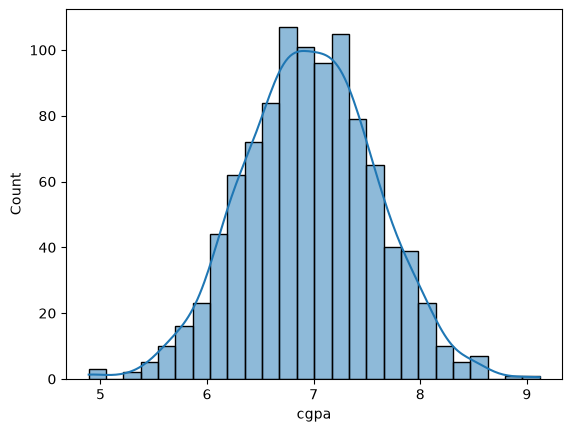

In [9]:
sns.histplot(df['cgpa'], kde=True)

The data of cgpa is normally distributed

In [12]:
# method 1
upper_limit = df['cgpa'].mean()+3*df['cgpa'].std()
lower_limit = df['cgpa'].mean()-3*df['cgpa'].std()

In [21]:
df.where(df['cgpa'].abs()<upper_limit, upper_limit)

,cgpa,placement_exam_marks,placed
0,7.190000,26.000000,1.000000
1,7.460000,38.000000,1.000000
2,7.540000,40.000000,1.000000
3,6.420000,8.000000,1.000000
4,7.230000,17.000000,0.000000
...,...,...,...
995,8.808934,8.808934,8.808934
996,8.808934,8.808934,8.808934
997,4.890000,34.000000,0.000000
998,8.620000,46.000000,1.000000


In [24]:
# Trimming 
new = df[df['cgpa'].abs() < upper_limit]
new

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
993,6.73,21.0,1
994,6.48,63.0,0
997,4.89,34.0,0
998,8.62,46.0,1


In [31]:
# Capping
np.where(
    df['cgpa'] > upper_limit,
    upper_limit,
    np.where(
        df['cgpa'] < lower_limit,
        lower_limit,
        df['cgpa']
    )
)

array([7.19      , 7.46      , 7.54      , 6.42      , 7.23      ,
       7.3       , 6.69      , 7.12      , 6.45      , 7.75      ,
       6.82      , 6.38      , 6.58      , 5.68      , 7.91      ,
       7.1       , 6.53      , 7.56      , 6.93      , 7.63      ,
       6.69      , 7.43      , 6.76      , 6.05      , 6.44      ,
       6.28      , 7.45      , 6.53      , 7.23      , 6.51      ,
       7.46      , 7.66      , 5.91      , 6.23      , 8.15      ,
       7.48      , 6.85      , 8.51      , 6.58      , 7.25      ,
       6.6       , 6.7       , 7.46      , 7.85      , 7.88      ,
       6.92      , 7.3       , 6.92      , 6.29      , 8.23      ,
       6.2       , 6.24      , 7.53      , 6.69      , 8.42      ,
       8.12      , 6.93      , 7.73      , 7.34      , 7.7       ,
       7.94      , 7.51      , 7.61      , 6.22      , 6.98      ,
       6.27      , 6.67      , 8.04      , 6.58      , 7.41      ,
       6.98      , 6.13      , 7.9       , 6.39      , 6.16   